<a href="https://colab.research.google.com/github/jefersonferreirafagundes-eng/MVP-ML-Analytics/blob/main/JFF_MVP_An%C3%A1lise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Nome: JEFERSON FERREIRA FAGUNDES*
 MVP Machine Learning e Analytics

 Matricula: 4052026000082

 Dataset: student_productivity_distraction_dataset_20000 - extraído da Kaggle

## **Descrição do Problema**
 Identificar se o uso de redes sociais, games, youtube, nível de stress estão associados ao desempenho na nota de exame e também verificar se outras variáveis como horas de sono e minutos de exercício colaboram para uma maior produtividade, classificados
 por gênero.


## **Tipo de Problema**
 Este é um problema de classificação supervisionada. Dado um conjunto de informações
 sobre os hábitos de estudo de alunos combinados com os tempos gastos em redes sociais, youtube,
 tefefone, games, vamos verificar as horas de sono e tempo de exercicios para saber se
 alteram as notas finais, reduz o nível de stress e aumenta a pontuação do foco.


## **Seleção de Dados**

 O dataset escolhido é um conjunto de dados amplamente disponível e incluído em bibliotecas de aprendizado de máquina no Python.


##  **Atributos do Dataset**

 O dataset "student_productivity_distraction_dataset_20000.csv" possui 6000 registros.

 **Possui os seguintes atributos:**

 student_id,                             - identificação do aluno

 age,                                    - idade

 gender,                                 - sexo

 study_hours_per_day,                    - horas de estudo por dia

 sleep_hours,                            - horas de sono

 phone_usage_hours,                      - horas de uso do celular

 social_media_hours,                     - horas em mídias sociais

 youtube_hours,                          - horas de youtube

 gaming_hours,                           - horas de games

 breaks_per_day,                         - minutos de descanso diário

 coffee_intake_mg,                       - qtde de café ingerida

 exercise_minutes,                       - minutos de exercícios

 assignments_completed,                  - número de tarefas concluídas

 attendance_percentage,                  - percentual de atenção

 stress_level,                           - nível de stress

 focus_score,                            - nível de foco

 final_grade,                            - nota final

 productivity_score                      - score de produtividade


** ## Análise de Dados**

 Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset "student_productivity_distraction_dataset_20000.csv,
 visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.
 O dataset utilizado possui 6000 registros com 18 informações para cada um, as quais utilizaremos parte para buscar entender a relação descrita nas hipóteses descritas acima.

### Importando o pandas e as bibliotecas de gráficos que serão utilizadas

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

### importando o DATASET do meu ambiente no GitHub



In [42]:
url = 'https://raw.githubusercontent.com/jefersonferreirafagundes-eng/datasetmvp/refs/heads/main/student_productivity_distraction_dataset_20000.csv'
df = pd.read_csv(url)

### Lê o arquivo utilizando - primeira linha que contém o cabeçalho neste caso

In [43]:
dataset = pd.read_csv(url, delimiter=',')

## Breve visualização do dataset

In [44]:
dataset.head(30)

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
5,6,29,Other,7.18,3.52,4.02,3.74,1.42,0.16,10,392,12,3,47.58,10,70,59.48,47.31
6,7,21,Female,9.06,6.36,11.45,5.99,2.20,4.44,14,87,28,15,43.50,8,35,62.71,41.23
7,8,23,Female,6.37,4.86,3.31,1.37,4.36,5.13,2,152,103,17,75.22,6,59,52.22,53.81
8,9,26,Male,4.19,4.87,9.66,2.87,0.10,3.38,13,460,42,11,44.79,3,39,76.15,25.99
9,10,19,Female,7.28,9.56,2.13,0.81,1.35,2.55,7,416,107,6,79.15,10,73,88.53,73.18


### Carregar dataset na variável

In [52]:
df = pd.read_csv((url), nrows=20000)

### Mostrar estatisticas descritivas do dataset

In [46]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000
mean,3000.000000,22.987665,5.192992,6.548315,6.232802,3.987838,3.003029,2.971165,7.527421,249.278546,59.921987,9.455743,69.560238,5.459743,64.156859,70.212404,49.890387
std,1731.906464,3.770489,2.738754,2.021401,3.325129,2.292109,1.720860,1.744649,3.988004,143.643123,34.781204,5.826776,17.415432,2.882263,20.157389,17.173194,16.061158
min,1.000000,17.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.010000,1.000000,30.000000,40.000000,1.910000
25%,1500.500000,20.000000,2.825000,4.790000,3.350000,2.015000,1.510000,1.455000,4.000000,126.000000,30.000000,4.000000,54.235000,3.000000,47.000000,55.450000,38.220000
50%,3000.000000,23.000000,5.180000,6.560000,6.190000,3.980000,3.030000,2.960000,7.000000,249.000000,60.000000,9.000000,69.550000,5.000000,64.000000,70.100000,49.970000
75%,4499.500000,26.000000,7.560000,8.330000,9.105000,5.950000,4.480000,4.450000,11.000000,373.000000,91.000000,15.000000,84.800000,8.000000,81.000000,85.030000,61.560000
max,5999.000000,29.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,99.970000,10.000000,99.000000,99.990000,99.900000


### Agrupar e contar os registros por gênero

In [47]:
gender_counts = df['gender'].value_counts()

## Plotar Histograma agrupado por gênero

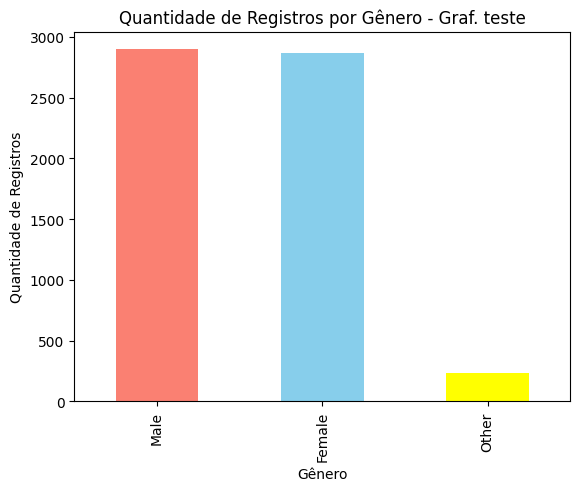

In [53]:
gender_counts.plot(kind='bar', color=['salmon', 'skyblue', 'yellow'])
plt.title('Quantidade de Registros por Gênero - Graf. teste')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Registros')
plt.show()

### Criar variável agregada de entretenimento digital

In [49]:
df["Horas Entretenimento"] = df["social_media_hours"] + df["youtube_hours"] + df["gaming_hours"]

### Separar por gênero

In [50]:
male = df[df["gender"] == "Male"]
female = df[df["gender"] == "Female"]


# Nova seção